# LiH compiled ansatz (FIG. 13)

Six-qubit `CZ` / `H` / `RX` circuit. **FIG. 10** prep is unchanged (includes `X` on `q0` and `q3`. The three `RX` gates on `q[1]` use separate symbols $\theta_1,\theta_2,\theta_3$ (paper-style). With **all three set to 0**, those rotations are identity.

**HF check:** On the **exported active-space Pauli Hamiltonian**, restricted HF is the computational ket **|100100⟩**, i.e. **only** `X` on `LineQubit(0)` and `LineQubit(3)`. The compiled FIG. 13 depth **does not** preserve that ket, so `⟨H⟩` at $\theta_i=0$ on the full circuit will **not** in general equal bare-RHF `⟨H⟩`. The next cell prints both the compiled value and the reference from `X(q0), X(q3)` alone.

**Noise:** Gate-only depolarizing via `GateArityDepolarizingNoise` (density-matrix `Tr[Hρ]`). Later cells add **finite-shot** energy (**OGM**, readout `p_0_success` / `p_1_success`, **REM**) and optional **CDR** calibration on near-Clifford training circuits (needs the same OGM + `SHADOWGROUPING_ROOT`).

0: ───Ry(-0.032π)───@───X───────────────────────I───Rx(0.5π)───@──────────────────────────────@───────@─────────────────────────────────────────────────────────────────────────@───Rx(-0.5π)───
                    │                           │              │                              │       │                                                                         │
1: ───H─────────────@───H───@───────────────────I──────────────@───────────@───Rx(0.2π)───@───@───H───@───@───@───Rx(0.2π)───@───────────────────────────@───Rx(0.2π)───@───@───@───H───────────
                            │                   │                          │              │               │   │              │                           │              │   │
2: ─────────────────────────┼───────────────────I───H──────────────────────┼──────────────┼───────────────@───┼──────────────┼───────────────────────────┼──────────────┼───@───H───────────────
                            │                   │                    

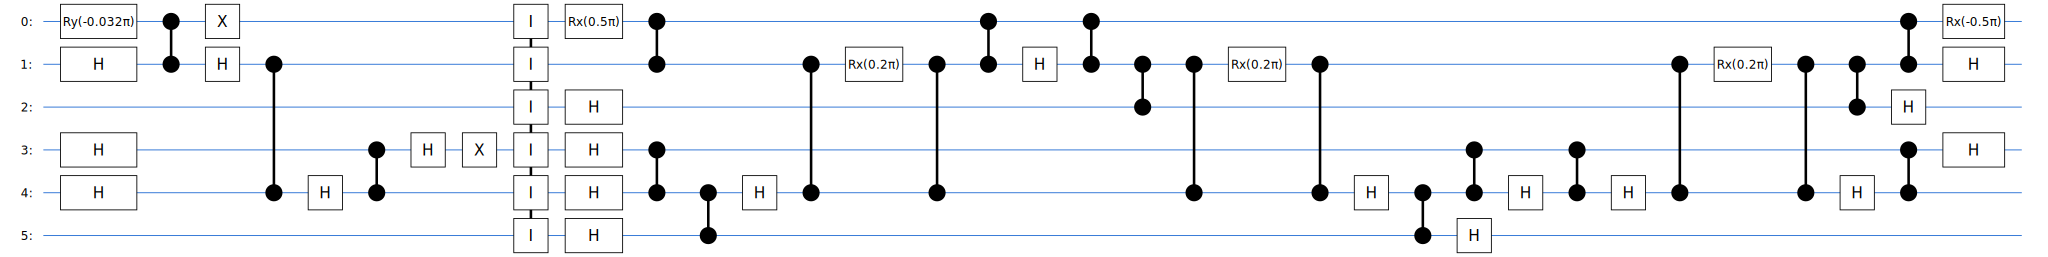

In [1]:
from __future__ import annotations

import cirq
import numpy as np
from cirq.ops import GlobalPhaseGate

# Needed for text/SVG diagrams: top-level ``cirq.GlobalPhaseGate`` can be missing in some kernels.
setattr(cirq, "GlobalPhaseGate", GlobalPhaseGate)

import sympy
from IPython.display import display

from cirq.contrib.svg import SVGCircuit

# Shared sampling/CDR settings used across later notebook cells.
GLOBAL_NUM_SHOTS = 8192
CDR_NUM_TRAINING_CIRCUITS = 30
CDR_T_MAX_GRADIENT = 2
CDR_T_MAX_VQE = CDR_T_MAX_GRADIENT
CDR_BASE_SEED = 42
GLOBAL_RANDOM_SEED = 1234
GLOBAL_SAMPLING_SEED = 1234
GLOBAL_MEASUREMENT_SCHEME = "ogm"
GLOBAL_APPLY_READOUT_NOISE = True
GLOBAL_READOUT_P0_SUCCESS = np.array([0.9756, 0.9748, 0.9738, 0.9656, 0.9585, 0.9514])
GLOBAL_READOUT_P1_SUCCESS = np.array([0.9756, 0.9748, 0.9738, 0.9656, 0.9585, 0.9514])


def lih_fig13_circuit(
    theta1: sympy.Symbol, theta2: sympy.Symbol, theta3: sympy.Symbol
) -> tuple[cirq.Circuit, list[cirq.LineQubit]]:
    """Compiled LiH ansatz (FIG. 13): three independent ``RX`` angles on ``q[1]``.

    """
    q = cirq.LineQubit.range(6)
    q0, q1, q2, q3, q4, q5 = q
    c = cirq.Circuit()
    ## this is for OG HF state
    # c.append(cirq.X(q0))
    # c.append(cirq.X(q3))

    ## multi reference state to start with 
    c.append(cirq.ry(-0.1).on(q0))
    c.append(cirq.H(q1))
    c.append(cirq.CZ(q0, q1))
    c.append(cirq.H(q1))
    c.append(cirq.H(q4))
    c.append(cirq.CZ(q1, q4))
    c.append(cirq.H(q4))
    c.append(cirq.H(q3))
    c.append(cirq.CZ(q4, q3))
    c.append(cirq.H(q3))
    c.append(cirq.X(q0))
    c.append(cirq.X(q3))
    c.append(cirq.identity_each(*q))  # visual barrier: multi-ref prep | FIG. 13 ansatz

    c.append(cirq.rx(np.pi / 2).on(q0))
    c.append(cirq.H(q2))
    c.append(cirq.H(q3))
    c.append(cirq.H(q4))
    c.append(cirq.H(q5))

    c.append([cirq.CZ(q0, q1), cirq.CZ(q3, q4)])
    c.append([cirq.CZ(q4, q5), cirq.H(q4)])

    c.append(cirq.CZ(q1, q4))
    c.append(cirq.rx(theta1).on(q1))
    c.append(cirq.CZ(q1, q4))

    c.append(cirq.CZ(q0, q1))
    c.append(cirq.H(q1))
    c.append(cirq.CZ(q0, q1))
    c.append(cirq.CZ(q1, q2))

    c.append(cirq.CZ(q1, q4))
    c.append(cirq.rx(theta2).on(q1))
    c.append(cirq.CZ(q1, q4))

    c.append(cirq.H(q4))
    c.append(cirq.CZ(q4, q5))
    c.append(cirq.H(q5))
    c.append(cirq.CZ(q3, q4))
    c.append(cirq.H(q4))
    c.append(cirq.CZ(q3, q4))
    c.append(cirq.H(q4))

    c.append(cirq.CZ(q1, q4))
    c.append(cirq.rx(theta3).on(q1))
    c.append(cirq.CZ(q1, q4))

    c.append(cirq.H(q4))
    c.append(cirq.CZ(q1, q2))
    c.append(cirq.H(q2))
    c.append(cirq.CZ(q0, q1))
    c.append(cirq.CZ(q3, q4))
    c.append(cirq.rx(-np.pi / 2).on(q0))
    c.append([cirq.H(q1), cirq.H(q3)])

    return c, q


theta1 = sympy.Symbol("theta1")
theta2 = sympy.Symbol("theta2")
theta3 = sympy.Symbol("theta3")
circuit, qubits = lih_fig13_circuit(theta1, theta2, theta3)

# Diagram with θ₁ = θ₂ = θ₃ = π/5 (paper-style visualization). HF check uses all zeros in the next cell.
_theta_viz = np.pi / 5
resolver_viz = cirq.ParamResolver({theta1: _theta_viz, theta2: _theta_viz, theta3: _theta_viz})
circuit_draw = cirq.resolve_parameters(circuit, resolver_viz)

print(circuit_draw)
display(SVGCircuit(circuit_draw))

In [2]:
import sys
from pathlib import Path

# Repo root resolution for local file loading.
_repo = Path.cwd().resolve()
if not (_repo / "main_cursor_lib.py").is_file():
    _repo = _repo.parent
sys.path.insert(0, str(_repo))


# Read numbered-Pauli Hamiltonian from Pauli_Ham/LiH_bond_<bond>.txt.
def load_pauli_sum_from_numbered_file(path: Path, qubits: list[cirq.Qid]) -> cirq.PauliSum:
    idx_to_pauli = {1: cirq.X, 2: cirq.Y, 3: cirq.Z}
    out = cirq.PauliSum()

    with path.open("r", encoding="utf-8") as f:
        for lineno, raw in enumerate(f, start=1):
            line = raw.strip()
            if not line:
                continue

            parts = line.split()
            coeff = float(parts[0])
            pauli_codes = [int(x) for x in parts[1:]]

            if len(pauli_codes) != len(qubits):
                raise ValueError(
                    f"{path}:{lineno} has {len(pauli_codes)} Pauli indices, expected {len(qubits)}."
                )

            pauli_string = cirq.PauliString()
            for q, code in zip(qubits, pauli_codes):
                if code == 0:
                    continue
                if code not in idx_to_pauli:
                    raise ValueError(f"{path}:{lineno} has invalid Pauli code {code}; expected 0/1/2/3.")
                pauli_string *= idx_to_pauli[code](q)

            out += coeff * pauli_string

    return out


bond_length = 1.5
ham_path = _repo / "Pauli_Ham" / f"LiH_bond_{bond_length:.1f}.txt"

# θ₁ = θ₂ = θ₃ = 0 → the three ``RX`` gates on ``q1`` are identity; FIG. 10 + FIG. 13 still apply other gates.
resolver = cirq.ParamResolver({theta1: 0.0, theta2: 0.0, theta3: 0.0})
resolved = cirq.resolve_parameters(circuit, resolver)

sim = cirq.Simulator()
result = sim.simulate(resolved, qubit_order=qubits)
psi = np.asarray(result.final_state_vector, dtype=np.complex128)

print(f"qubits: {len(qubits)}  state_dim: {len(psi)}")
assert len(psi) == 2 ** len(qubits)

pauli_sum = load_pauli_sum_from_numbered_file(ham_path, list(qubits))
qubit_map = {q: i for i, q in enumerate(qubits)}
e_gs = float(np.linalg.eigvalsh(pauli_sum.matrix(qubits=qubits))[0].real)
e_compiled = float(np.real(pauli_sum.expectation_from_state_vector(psi, qubit_map=qubit_map)))

# Reference: active-space ⟨H⟩ on spin-block RHF ket |100100⟩ = X on q0 and q3 only (no FIG. 10 / FIG. 13).
# psi_hf = cirq.Simulator().simulate(
#     cirq.Circuit(cirq.X(qubits[0]), cirq.X(qubits[3])),
#     qubit_order=qubits,
# ).final_state_vector
# e_hf_ref = float(
#     np.real(pauli_sum.expectation_from_state_vector(np.asarray(psi_hf, dtype=np.complex128), qubit_map=qubit_map))
# )

# or multi-reference state

psi_hf = cirq.Simulator().simulate(
    cirq.Circuit(
    cirq.ry(-0.034).on(qubits[0]), # -0.1 for 2.2 bond length
    cirq.H(qubits[1]),
    cirq.CZ(qubits[0], qubits[1]),
    cirq.H(qubits[1]),
    cirq.H(qubits[4]),
    cirq.CZ(qubits[1], qubits[4]),
    cirq.H(qubits[4]),
    cirq.H(qubits[3]),
    cirq.CZ(qubits[4], qubits[3]),
    cirq.H(qubits[3]),
    cirq.X(qubits[0]),
    cirq.X(qubits[3])
        ),
    qubit_order=qubits,
).final_state_vector
e_hf_ref = float(
    np.real(pauli_sum.expectation_from_state_vector(np.asarray(psi_hf, dtype=np.complex128), qubit_map=qubit_map))
)

print(f"\nLiH bond {bond_length} Å")
print(f"Hamiltonian source: {ham_path}")
print(f"⟨H⟩ compiled FIG. 10 + FIG. 13 with θ₁=θ₂=θ₃=0: {e_compiled:.10f} Eh")
#print(f"⟨H⟩ reference |100100⟩ (X on LineQubit(0) and LineQubit(3) only): {e_hf_ref:.10f} Eh")
print(f"⟨H⟩ multi reference: {e_hf_ref:.10f} Eh")
print(f"Ground-state energy e_gs (exact): {e_gs:.10f} Eh")

qubits: 6  state_dim: 64

LiH bond 1.5 Å
Hamiltonian source: /Users/zacharyhe/cross_chips_sim/Pauli_Ham/LiH_bond_1.5.txt
⟨H⟩ compiled FIG. 10 + FIG. 13 with θ₁=θ₂=θ₃=0: -7.8628310836 Eh
⟨H⟩ multi reference: -7.8635693683 Eh
Ground-state energy e_gs (exact): -7.8810157156 Eh


In [3]:
# # --- VQE: optimize RY(α) on q0 in multi-reference prep (noiseless ⟨H⟩) ---
# # Requires the simulate cell above (pauli_sum, qubits, qubit_map, e_gs).

# _sim_prep = cirq.Simulator()
# RY_PARAM_SHIFT = np.pi / 2.0
# VQE_RY_ITERS = 50
# VQE_RY_LR = 0.2


# def multi_ref_prep_circuit(alpha: float) -> cirq.Circuit:
#     return cirq.Circuit(
#         cirq.ry(alpha).on(qubits[0]),
#         cirq.H(qubits[1]),
#         cirq.CZ(qubits[0], qubits[1]),
#         cirq.H(qubits[1]),
#         cirq.H(qubits[4]),
#         cirq.CZ(qubits[1], qubits[4]),
#         cirq.H(qubits[4]),
#         cirq.H(qubits[3]),
#         cirq.CZ(qubits[4], qubits[3]),
#         cirq.H(qubits[3]),
#         cirq.X(qubits[0]),
#         cirq.X(qubits[3]),
#     )


# def prep_energy(alpha: float) -> float:
#     psi = np.asarray(
#         _sim_prep.simulate(multi_ref_prep_circuit(alpha), qubit_order=qubits).final_state_vector,
#         dtype=np.complex128,
#     )
#     return float(np.real(pauli_sum.expectation_from_state_vector(psi, qubit_map=qubit_map)))


# def prep_energy_grad(alpha: float) -> float:
#     return 0.5 * (
#         prep_energy(alpha + RY_PARAM_SHIFT) - prep_energy(alpha - RY_PARAM_SHIFT)
#     )


# alpha = 0.0
# ry_vqe_trace: list[tuple[float, float]] = []
# for it in range(VQE_RY_ITERS + 1):
#     e = prep_energy(alpha)
#     ry_vqe_trace.append((float(alpha), float(e)))
#     if it == VQE_RY_ITERS:
#         break
#     alpha = alpha - VQE_RY_LR * prep_energy_grad(alpha)

# alpha_vqe, e_vqe = ry_vqe_trace[-1]

# # Cross-check with bounded 1D search on [-π, π].
# from scipy.optimize import minimize_scalar

# opt = minimize_scalar(prep_energy, bounds=(-np.pi, np.pi), method="bounded")
# alpha_opt = float(opt.x)
# e_opt = float(opt.fun)

# print("Multi-ref prep VQE: minimize ⟨H⟩ w.r.t. RY(α) on LineQubit(0)")
# print(f"  α = 0 (HF check cell):      E = {prep_energy(0.0):.10f} Eh")
# print(f"  α = -0.1 (FIG. 13 circuit): E = {prep_energy(-0.1):.10f} Eh")
# print(
#     f"  parameter-shift GD ({VQE_RY_ITERS} steps, lr={VQE_RY_LR}): "
#     f"α = {alpha_vqe:.6f}  E = {e_vqe:.10f} Eh"
# )
# print(f"  scipy bounded [-π, π]:      α = {alpha_opt:.6f}  E = {e_opt:.10f} Eh")
# print(f"  Ground-state e_gs:          {e_gs:.10f} Eh")
# print(f"  |E_opt - e_gs|:             {abs(e_opt - e_gs):.6e} Eh")

In [4]:
# Evaluate FIG. 13 compiled ansatz energy at params = [0.0, 0.07, 0.0].
params = np.array([-0.195078, 0.490895, 0.195077], dtype=float) # 2.2 bond length 
params = np.array( [-0.128705, 0.233859, 0.114671], dtype=float) # 1.5 bond length 
resolver_test = cirq.ParamResolver({theta1: params[0], theta2: params[1], theta3: params[2]})

resolved_test = cirq.resolve_parameters(circuit, resolver_test)
psi_test = np.asarray(
    cirq.Simulator().simulate(resolved_test, qubit_order=qubits).final_state_vector,
    dtype=np.complex128,
)
e_test = float(np.real(pauli_sum.expectation_from_state_vector(psi_test, qubit_map=qubit_map)))

print(f"params = {params.tolist()}")
print(f"E(params) = {e_test:.10f} Eh")

params = [-0.128705, 0.233859, 0.114671]
E(params) = -7.8798156480 Eh


In [5]:
# Noisy energy: ``GateArityDepolarizingNoise`` adds single-qubit depolarizing channels after
# each gate — 2Q gates → ``two_qubit_depol_prob`` on both lines; 1Q gates → ``one_qubit_depol_prob``.
# No measurement noise here (density matrix + Tr[H ρ]).
import sys
from pathlib import Path

_repo = Path.cwd().resolve()
if not (_repo / "main_cursor_lib.py").is_file():
    _repo = _repo.parent
for _p in (str(_repo), str(_repo / "test_LiH_case")):
    if _p not in sys.path:
        sys.path.insert(0, _p)

from main_cursor_lib_test_LiH import (
    GateArityDepolarizingNoise,
    ONE_QUBIT_GATE_DEPOL_PROB,
    TWO_QUBIT_GATE_DEPOL_PROB,
    trace_energy,
)

random_seed = int(globals()["GLOBAL_RANDOM_SEED"])

gate_noise = GateArityDepolarizingNoise(
    two_qubit_depol_prob=TWO_QUBIT_GATE_DEPOL_PROB,
    one_qubit_depol_prob=ONE_QUBIT_GATE_DEPOL_PROB,
)
noisy_ansatz = circuit.with_noise(gate_noise)
resolver_noisy = cirq.ParamResolver(
    {theta1: float(params[0]), theta2: float(params[1]), theta3: float(params[2])}
)
resolved_noisy = cirq.resolve_parameters(noisy_ansatz, resolver_noisy)

rho_noisy = np.asarray(
    cirq.DensityMatrixSimulator(seed=random_seed)
    .simulate(resolved_noisy, qubit_order=qubits)
    .final_density_matrix,
    dtype=np.complex128,
)

hamiltonian_matrix = pauli_sum.matrix(qubits=qubits)
trace_noisy_energy = trace_energy(hamiltonian_matrix, rho_noisy)

print(
    f"noise: two_qubit_depol={gate_noise.two_qubit_depol_prob} "
    f"one_qubit_depol={gate_noise.one_qubit_depol_prob}"
)
print(f"params = {params.tolist()}")
print(f"Tr[H ρ_noisy] (gate noise only): {trace_noisy_energy:.10f} Eh")

noise: two_qubit_depol=0.018 one_qubit_depol=0.0018
params = [-0.128705, 0.233859, 0.114671]
Tr[H ρ_noisy] (gate noise only): -7.6710405116 Eh


In [6]:
# Finite-shot energy from the same ``rho_noisy`` as above: OGM measurement layout + asymmetric
# readout (``p_0_success`` / ``p_1_success`` on LineQubit 0…5) and optional REM in post-processing.
# This cell is kept compatible with the current gate-arity depolarizing workflow
# (no legacy DEFAULT_AMP_DAMP_GAMMA / LocationAware noise constants in main_cursor_lib_test_LiH).
import sys
from pathlib import Path

_repo = Path.cwd().resolve()
if not (_repo / "main_cursor_lib.py").is_file():
    _repo = _repo.parent
for _p in (str(_repo), str(_repo / "test_LiH_case")):
    if _p not in sys.path:
        sys.path.insert(0, _p)

# Prefer the test helper, but fall back to the shared helper if the test helper still
# references removed legacy noise constants.
try:
    from shot_measurement_test_LiH import estimate_energy_from_noisy_rho_shots
except ImportError:
    from shot_measurement import estimate_energy_from_noisy_rho_shots

num_shots = int(globals()["GLOBAL_NUM_SHOTS"])
measurement_scheme = str(globals()["GLOBAL_MEASUREMENT_SCHEME"])
sampling_seed = int(globals()["GLOBAL_SAMPLING_SEED"])
epsilon = 0.1

p_0_success = np.array(globals()["GLOBAL_READOUT_P0_SUCCESS"], dtype=float)
p_1_success = np.array(globals()["GLOBAL_READOUT_P1_SUCCESS"], dtype=float)

apply_readout_noise = bool(globals()["GLOBAL_APPLY_READOUT_NOISE"])
apply_rem = True

SHADOWGROUPING_ROOT = globals().get("SHADOWGROUPING_ROOT", "/Users/zacharyhe/shadowgrouping")
ogm_file = globals().get(
    "ogm_file",
    Path(f"{SHADOWGROUPING_ROOT}/haozhaowu/LiH/hamil_class/ogm_outputs/OGM_ogm_LiH_{bond_length:.1f}.txt"),
)

print(f"OGM file: {ogm_file}  exists={ogm_file.is_file()}")

if not ogm_file.is_file():
    print(
        "Skip OGM shot estimate: OGM file missing. Generate LiH OGM at this bond or set SHADOWGROUPING_ROOT."
    )
elif not Path(SHADOWGROUPING_ROOT).is_dir():
    print("Skip OGM shot estimate: SHADOWGROUPING_ROOT does not exist.")
else:
    try:
        shot_est = estimate_energy_from_noisy_rho_shots(
            rho_noisy,
            pauli_sum,
            qubits,
            num_shots=num_shots,
            measurement_scheme=measurement_scheme,
            p_0_success=p_0_success,
            p_1_success=p_1_success,
            apply_rem=apply_rem,
            apply_readout_noise=apply_readout_noise,
            sampling_seed=sampling_seed,
            epsilon=epsilon,
            ogm_file=ogm_file,
            shadowgrouping_root=SHADOWGROUPING_ROOT,
        )
        eu = float(shot_est["energy_unmitigated"])
        er = float(shot_est["energy_rem"])

        print(f"Finite-shot energy (readout noise, no REM correction): {eu:.12f} Eh")
        print(f"Finite-shot energy (REM readout mitigation):          {er:.12f} Eh")
        print(f"REM delta (REM - raw shots):                            {er - eu:.12f} Eh")
        print(
            f"\nReference Tr[H ρ] (same ρ, exact Pauli from DM; no shot noise): {trace_noisy_energy:.12f} Eh"
        )
    except Exception:
        raise

OGM file: /Users/zacharyhe/shadowgrouping/haozhaowu/LiH/hamil_class/ogm_outputs/OGM_ogm_LiH_1.5.txt  exists=True
Finite-shot energy (readout noise, no REM correction): -7.612563795165 Eh
Finite-shot energy (REM readout mitigation):          -7.666257973910 Eh
REM delta (REM - raw shots):                            -0.053694178745 Eh

Reference Tr[H ρ] (same ρ, exact Pauli from DM; no shot noise): -7.671040511594 Eh


n_shots=   8192: mean(|REM-ref|)=9.048031e-03 Eh  std=6.597830e-03 Eh
n_shots=  16384: mean(|REM-ref|)=5.641912e-03 Eh  std=4.630221e-03 Eh
n_shots=  32768: mean(|REM-ref|)=5.323749e-03 Eh  std=4.554221e-03 Eh
n_shots=  81920: mean(|REM-ref|)=2.898559e-03 Eh  std=2.204629e-03 Eh
n_shots= 819200: mean(|REM-ref|)=7.881671e-04 Eh  std=4.699364e-04 Eh


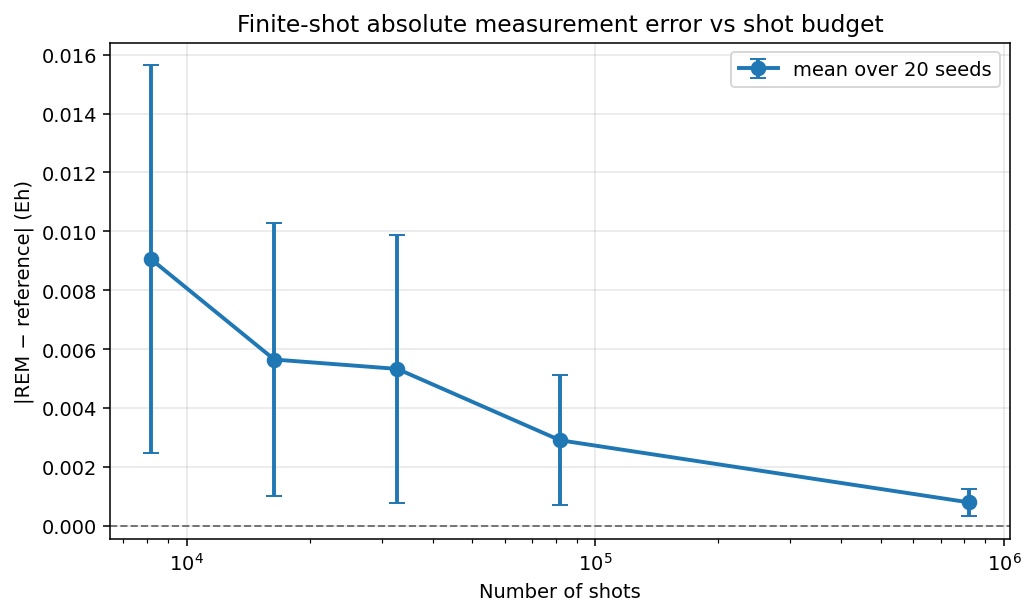

In [7]:
# Measurement error vs shot budget: mean(|REM - reference|) over independent shot seeds.
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

_repo = Path.cwd().resolve()
if not (_repo / "main_cursor_lib.py").is_file():
    _repo = _repo.parent
for _p in (str(_repo), str(_repo / "test_LiH_case")):
    if _p not in sys.path:
        sys.path.insert(0, _p)

try:
    from shot_measurement_test_LiH import (
        estimate_energy_from_noisy_rho_shots,
        sanitize_density_matrix,
    )
except ImportError:
    from shot_measurement import (
        estimate_energy_from_noisy_rho_shots,
        sanitize_density_matrix,
    )

# Same shot/readout settings as the finite-shot cell above (LiH OGM + REM).
measurement_scheme = str(globals().get("measurement_scheme", globals()["GLOBAL_MEASUREMENT_SCHEME"]))
sampling_seed = int(globals().get("sampling_seed", globals()["GLOBAL_SAMPLING_SEED"]))
epsilon = float(globals().get("epsilon", 0.1))
p_0_success = np.array(globals().get("p_0_success", globals()["GLOBAL_READOUT_P0_SUCCESS"]), dtype=float)
p_1_success = np.array(globals().get("p_1_success", globals()["GLOBAL_READOUT_P1_SUCCESS"]), dtype=float)
apply_readout_noise = bool(globals().get("apply_readout_noise", globals()["GLOBAL_APPLY_READOUT_NOISE"]))
apply_rem = bool(globals().get("apply_rem", True))

SHADOWGROUPING_ROOT = globals().get("SHADOWGROUPING_ROOT", "/Users/zacharyhe/shadowgrouping")
ogm_file = globals().get(
    "ogm_file",
    Path(f"{SHADOWGROUPING_ROOT}/haozhaowu/LiH/hamil_class/ogm_outputs/OGM_ogm_LiH_{bond_length:.1f}.txt"),
)

# Exact Tr[H rho_noisy] from the gate-noise DM cell (main.ipynb uses e_noisy_adj for the same role).
energy_reference = float(globals()["trace_noisy_energy"])

if not Path(ogm_file).is_file():
    print(f"Skip shot-budget sweep: OGM file missing ({ogm_file}).")
elif not Path(SHADOWGROUPING_ROOT).is_dir():
    print("Skip shot-budget sweep: SHADOWGROUPING_ROOT does not exist.")
else:
    rho_noisy_for_shots = sanitize_density_matrix(rho_noisy)

    shot_budgets = [
        8192,
        8192 * 2,
        8192 * 4,
        8192 * 10,
        8192 * 100,
    ]
    num_replicates = 20
    base_seed = int(globals().get("GLOBAL_SAMPLING_SEED", sampling_seed))

    mean_errors = []
    std_errors = []
    for n_shots in shot_budgets:
        errs = []
        for rep in range(num_replicates):
            est = estimate_energy_from_noisy_rho_shots(
                rho_noisy_for_shots,
                pauli_sum,
                list(qubits),
                num_shots=int(n_shots),
                measurement_scheme=measurement_scheme,
                p_0_success=p_0_success,
                p_1_success=p_1_success,
                apply_rem=apply_rem,
                apply_readout_noise=apply_readout_noise,
                sampling_seed=base_seed + rep,
                epsilon=epsilon,
                ogm_file=ogm_file,
                shadowgrouping_root=SHADOWGROUPING_ROOT,
            )
            errs.append(abs(float(est["energy_rem"]) - energy_reference))
        mean_errors.append(float(np.mean(errs)))
        std_errors.append(float(np.std(errs, ddof=1)))
        print(
            f"n_shots={n_shots:7d}: mean(|REM-ref|)={mean_errors[-1]:.6e} Eh  "
            f"std={std_errors[-1]:.6e} Eh"
        )

    fig, ax = plt.subplots(figsize=(7.5, 4.5), dpi=140)
    ax.errorbar(
        shot_budgets,
        mean_errors,
        yerr=std_errors,
        fmt="o-",
        capsize=4,
        lw=2,
        ms=7,
        color="tab:blue",
        label=f"mean over {num_replicates} seeds",
    )
    ax.axhline(0.0, color="0.45", ls="--", lw=1)
    ax.set_xscale("log")
    ax.set_xlabel("Number of shots")
    ax.set_ylabel("|REM − reference| (Eh)")
    ax.set_title("Finite-shot absolute measurement error vs shot budget")
    ax.grid(True, alpha=0.3)
    ax.legend(loc="best")
    plt.tight_layout()
    plt.show()

In [8]:
# Head-to-head: default per-Pauli CDR vs legacy total-energy CDR (same config, mode='cdr').
import sys
from pathlib import Path

import cirq
import numpy as np

_repo = Path.cwd().resolve()
if not (_repo / "main_cursor_lib.py").is_file():
    _repo = _repo.parent
for _p in (str(_repo), str(_repo / "test_LiH_case")):
    if _p not in sys.path:
        sys.path.insert(0, _p)

from main_cursor_lib_test_LiH import (
    ONE_QUBIT_GATE_DEPOL_PROB,
    TWO_QUBIT_GATE_DEPOL_PROB,
    run_cdr_with_per_pauli_coeff_print,
)
try:
    from shot_measurement_test_LiH import run_mitigation
except ImportError:
    from shot_measurement import run_mitigation

symbols_li_h = [theta1, theta2, theta3]
target_resolver = {theta1: float(params[0]), theta2: float(params[1]), theta3: float(params[2])}

base_noise_cfg = {
    "two_qubit_depol_prob": TWO_QUBIT_GATE_DEPOL_PROB,
    "one_qubit_depol_prob": ONE_QUBIT_GATE_DEPOL_PROB,
}

shot_cfg = {
    "num_shots": int(globals().get("num_shots", globals()["GLOBAL_NUM_SHOTS"])),
    "measurement_scheme": str(globals().get("measurement_scheme", globals()["GLOBAL_MEASUREMENT_SCHEME"])),
    "apply_readout_noise": bool(globals().get("apply_readout_noise", globals()["GLOBAL_APPLY_READOUT_NOISE"])),
    "sampling_seed": int(globals().get("sampling_seed", globals()["GLOBAL_SAMPLING_SEED"])),
    "ogm_file": globals().get(
        "ogm_file",
        Path(
            f"{globals().get('SHADOWGROUPING_ROOT', '/Users/zacharyhe/shadowgrouping')}/haozhaowu/LiH/hamil_class/ogm_outputs/OGM_ogm_LiH_{bond_length:.1f}.txt"
        ),
    ),
    "shadowgrouping_root": globals().get("SHADOWGROUPING_ROOT", "/Users/zacharyhe/shadowgrouping"),
}
readout_cal = {
    "p_0_success": np.array(globals().get("p_0_success", globals()["GLOBAL_READOUT_P0_SUCCESS"]), dtype=float),
    "p_1_success": np.array(globals().get("p_1_success", globals()["GLOBAL_READOUT_P1_SUCCESS"]), dtype=float),
}

cdr_cfg_base = dict(
    num_circuits=int(globals().get("CDR_NUM_TRAINING_CIRCUITS", globals()["CDR_NUM_TRAINING_CIRCUITS"])),
    t_max=int(globals().get("CDR_T_MAX_VQE", globals()["CDR_T_MAX_VQE"])),
    seed=int(globals().get("CDR_BASE_SEED", globals()["CDR_BASE_SEED"])),
)

if not Path(shot_cfg["shadowgrouping_root"]).is_dir() or not Path(shot_cfg["ogm_file"]).is_file():
    print("Skip CDR: need valid ogm_file and SHADOWGROUPING_ROOT (same as OGM shot cell).")
else:
    mit_pp = run_cdr_with_per_pauli_coeff_print(
        ansatz_circuit=circuit,
        observable_h=pauli_sum,
        qubits=qubits,
        target_resolver=target_resolver,
        target_params=target_resolver,
        symbols=symbols_li_h,
        base_noise_cfg=base_noise_cfg,
        shot_cfg=shot_cfg,
        readout_cal=readout_cal,
        cdr_cfg={**cdr_cfg_base},
        simulator_seed=int(globals().get("random_seed", globals()["GLOBAL_RANDOM_SEED"])),
    )
    if "e_test" in globals():
        eref = float(e_test)
    else:
        resolved_target = cirq.resolve_parameters(circuit, cirq.ParamResolver(target_resolver))
        psi_target = cirq.Simulator(
            seed=int(globals().get("random_seed", globals()["GLOBAL_RANDOM_SEED"]))
        ).simulate(resolved_target, qubit_order=qubits).final_state_vector
        h_mat = pauli_sum.matrix(qubits=qubits)
        eref = float(np.vdot(psi_target, h_mat @ psi_target).real)

    print("CDR (per-pauli)")
    print(
        f"raw finite-shot (unmit / REM): {float(mit_pp['unmit_target']):.12f} / {float(mit_pp['rem_target']):.12f} Eh"
    )
    print(
        "cdr corrected (unmit / REM): "
        f"{float(mit_pp['cdr_unmit_corrected']):.12f} / {float(mit_pp['cdr_rem_corrected']):.12f} Eh"
    )
    print(f"reference exact noiseless: {eref:.12f} Eh")
    print(f"Energy error: {eref - float(mit_pp['cdr_rem_corrected']):.12f} Eh")

CDR per-Pauli coefficients (exact_k ~= a_k * noisy_k + b_k)
Number of Pauli terms: 117
REM branch coefficients:
term[000] XXIIII  weight= 0.011733624357  a= 0.000000019060, b= 0.000000000016
term[001] XXZZII  weight= 0.002775746412  a=-0.000000006373, b=-0.000000000615
term[002] XXZZXX  weight= 0.002111137889  a=-0.000000002609, b=-0.000000007370
term[003] XXZZYY  weight= 0.002111137889  a=-0.000000006421, b= 0.000000001806
term[004] XXIZII  weight=-0.000041638126  a= 0.000000001434, b=-0.000000000319
term[005] XXIZZI  weight=-0.001540670231  a= 0.000000000381, b= 0.000000000547
term[006] XXIZIZ  weight= 0.010540187793  a= 0.000000006583, b= 0.000000000197
term[007] XYZXZY  weight= 0.008373361677  a= 1.241406627542, b=-0.013363500140
term[008] XYZYZX  weight=-0.008373361677  a= 0.962828441955, b= 0.047111376430
term[009] XYIXYI  weight=-0.003034657024  a= 0.054169207808, b=-0.002002321183
term[010] XYIYXI  weight= 0.003034657024  a= 0.154019923568, b=-0.069534223359
term[011] XZXZII  w

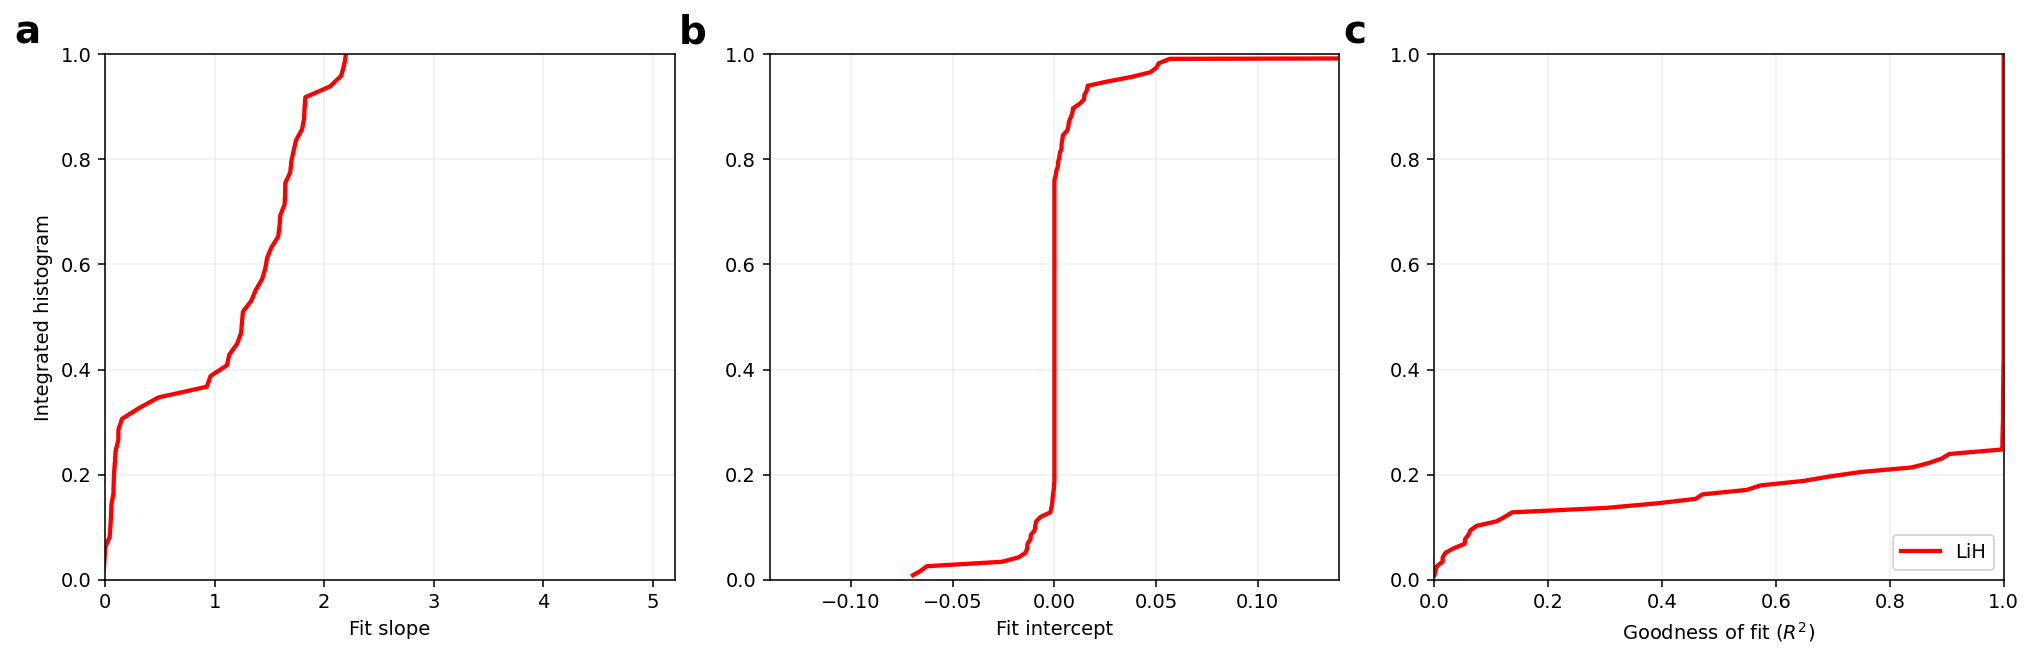

LiH terms total: 117
Panel a terms (excl. a≈b≈0): 49 (dropped 68)
Panel a slope (a): mean=1.059081, std=0.747109
All terms slope (a): mean=0.443547, std=0.711886
Intercept (b): mean=0.009141, std=0.093357
R^2: mean=0.838341, std=0.328591


In [11]:
# Cumulative histograms for LiH per-Pauli CDR fit coefficients (REM branch):
# exact_k ~= a_k * noisy_k + b_k
import numpy as np
import matplotlib.pyplot as plt

if "mit_pp" not in globals():
    raise RuntimeError("Run the CDR cell above first to create `mit_pp`.")

models = dict(mit_pp.get("cdr_models", {}))
coeffs_rem = np.asarray(models.get("coeffs_rem_to_exact_per_term", []), dtype=float)
r2_vals = np.asarray(models.get("r2_rem_to_exact_per_term", []), dtype=float)

if coeffs_rem.size == 0:
    raise RuntimeError("No per-Pauli coefficients found in mit_pp['cdr_models'].")
if coeffs_rem.ndim != 2 or coeffs_rem.shape[1] < 2:
    raise RuntimeError(f"Unexpected coeff shape: {coeffs_rem.shape}")
if r2_vals.size == 0:
    raise RuntimeError(
        "No per-Pauli R^2 values found. Re-run the CDR cell above after updating shot_measurement."
    )
if r2_vals.shape[0] != coeffs_rem.shape[0]:
    raise RuntimeError(
        f"R^2 length {r2_vals.shape[0]} != coefficient rows {coeffs_rem.shape[0]}"
    )

a_vals = np.asarray(coeffs_rem[:, 0], dtype=float)
b_vals = np.asarray(coeffs_rem[:, 1], dtype=float)

# Panel a only: exclude terms where both slope and intercept are ~0.
zero_pair_mask = np.isclose(a_vals, 0.0, atol=5e-3) & np.isclose(b_vals, 0.0, atol=5e-3)
a_vals_panel_a = a_vals[~zero_pair_mask]
if a_vals_panel_a.size == 0:
    raise RuntimeError("Panel a: all terms have both slope and intercept near zero (atol=5e-3).")


def _empirical_cdf(values: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    x = np.sort(np.asarray(values, dtype=float))
    y = np.arange(1, len(x) + 1, dtype=float) / float(len(x))
    return x, y

x_a, y_a = _empirical_cdf(a_vals_panel_a)
x_b, y_b = _empirical_cdf(b_vals)
x_c, y_c = _empirical_cdf(r2_vals)

fig, axes = plt.subplots(1, 3, figsize=(14.5, 4.8), dpi=140)
lih_color = "red"  # warm orange/yellow close to the reference figure

axes[0].plot(x_a, y_a, color=lih_color, lw=2.2, label="LiH")
axes[0].set_xlabel("Fit slope")
axes[0].set_ylabel("Integrated histogram")
axes[0].set_xlim(0, 5.2)
axes[0].set_ylim(0.0, 1.0)
axes[0].text(-0.16, 1.02, "a", transform=axes[0].transAxes, fontsize=20, fontweight="bold")

axes[1].plot(x_b, y_b, color=lih_color, lw=2.2, label="LiH")
axes[1].set_xlabel("Fit intercept")
axes[1].set_xlim(-0.14, 0.14)
axes[1].set_ylim(0.0, 1.0)
axes[1].text(-0.16, 1.02, "b", transform=axes[1].transAxes, fontsize=20, fontweight="bold")

axes[2].plot(x_c, y_c, color=lih_color, lw=2.2, label="LiH")
axes[2].set_xlabel(r"Goodness of fit ($R^2$)")
axes[2].set_xlim(0.0, 1.0)
axes[2].set_ylim(0.0, 1.0)
axes[2].text(-0.16, 1.02, "c", transform=axes[2].transAxes, fontsize=20, fontweight="bold")
axes[2].legend(loc="lower right", frameon=True)

for ax in axes:
    ax.grid(alpha=0.18)

plt.tight_layout()
plt.show()

print(f"LiH terms total: {len(a_vals)}")
print(f"Panel a terms (excl. a≈b≈0): {len(a_vals_panel_a)} (dropped {int(zero_pair_mask.sum())})")
print(f"Panel a slope (a): mean={np.mean(a_vals_panel_a):.6f}, std={np.std(a_vals_panel_a):.6f}")
print(f"All terms slope (a): mean={np.mean(a_vals):.6f}, std={np.std(a_vals):.6f}")
print(f"Intercept (b): mean={np.mean(b_vals):.6f}, std={np.std(b_vals):.6f}")
print(f"R^2: mean={np.mean(r2_vals):.6f}, std={np.std(r2_vals):.6f}")

Reusing cached cdr_training_tex_exact/cdr_training_trem.


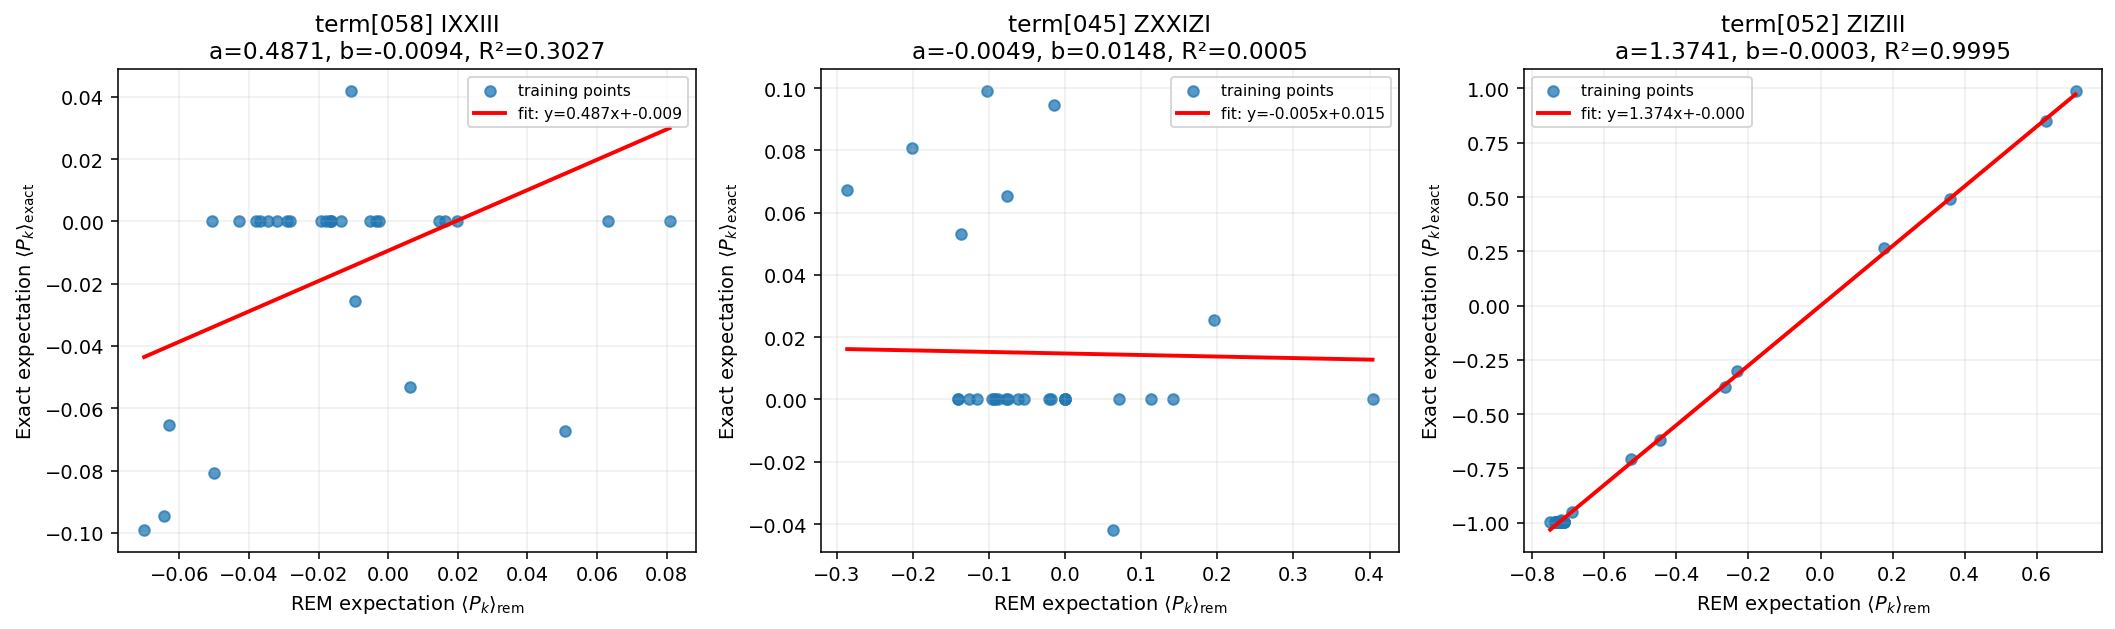

Selected low-a terms for diagnostics:
  term[058] IXXIII: a=0.487127, b=-0.009404, R^2=0.302710, OGM_eff=903, 1/sqrt(OGM_eff)=3.327792e-02, 
  term[045] ZXXIZI: a=-0.004918, b=0.014773, R^2=0.000493, OGM_eff=76, 1/sqrt(OGM_eff)=1.147079e-01, 
  term[052] ZIZIII: a=1.374147, b=-0.000318, R^2=0.999486, OGM_eff=4546, 1/sqrt(OGM_eff)=1.483151e-02, 


In [14]:
# Low-a per-term diagnostics: plot training-data fit quality for REM branch.
# Targets include terms with slope a near 0.5 and 0.3 (a < 1).
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

if "mit_pp" not in globals():
    raise RuntimeError("Run the CDR cell above first to create `mit_pp`.")

models = dict(mit_pp.get("cdr_models", {}))
coeffs_rem = np.asarray(models.get("coeffs_rem_to_exact_per_term", []), dtype=float)
r2_vals = np.asarray(models.get("r2_rem_to_exact_per_term", []), dtype=float)

if coeffs_rem.size == 0:
    raise RuntimeError("No per-Pauli coefficients found in mit_pp['cdr_models'].")
if coeffs_rem.ndim != 2 or coeffs_rem.shape[1] < 2:
    raise RuntimeError(f"Unexpected coeff shape: {coeffs_rem.shape}")
if r2_vals.size == 0:
    raise RuntimeError("No per-Pauli R^2 values found in mit_pp['cdr_models'].")
if r2_vals.shape[0] != coeffs_rem.shape[0]:
    raise RuntimeError(
        f"R^2 length {r2_vals.shape[0]} != coefficient rows {coeffs_rem.shape[0]}"
    )

a_vals = np.asarray(coeffs_rem[:, 0], dtype=float)
b_vals = np.asarray(coeffs_rem[:, 1], dtype=float)
zero_pair_mask = np.isclose(a_vals, 0.0, atol=5e-3) & np.isclose(b_vals, 0.0, atol=5e-3)
low_a_mask = (a_vals < 1.0) & (~zero_pair_mask)
low_a_ids = np.where(low_a_mask)[0]
if low_a_ids.size == 0:
    raise RuntimeError("No usable low-a terms found (a<1 and not a≈b≈0).")


def _pick_closest_target(target: float, candidates: np.ndarray, arr: np.ndarray) -> int:
    return int(candidates[np.argmin(np.abs(arr[candidates] - float(target)))])


selected_ids: list[int] = []

# Plot 1: representative low-a term near 0.5
k_near_05 = _pick_closest_target(0.5, low_a_ids, a_vals)

# Plot 2: explicit bad case (lowest R^2 among low-a terms)
k_bad = int(low_a_ids[np.argmin(r2_vals[low_a_ids])])

for k in (k_near_05, k_bad):
    if int(k) not in selected_ids:
        selected_ids.append(int(k))

_repo = Path.cwd().resolve()
if not (_repo / "main_cursor_lib.py").is_file():
    _repo = _repo.parent
for _p in (str(_repo), str(_repo / "test_LiH_case")):
    if _p not in sys.path:
        sys.path.insert(0, _p)

from main_cursor_lib_test_LiH import (
    ONE_QUBIT_GATE_DEPOL_PROB,
    TWO_QUBIT_GATE_DEPOL_PROB,
    generate_near_clifford_param_sets,
)
try:
    from shot_measurement_test_LiH import (
        _generate_near_clifford_resolvers_fallback,
        _is_setting_compatible,
        _load_shadowgrouping_scheme,
        _simulate_noiseless_state_for_resolver,
        _simulate_noisy_rho_for_resolver,
        _unique_settings_with_counts,
        ensure_shadowgrouping_importable,
        estimate_energy_from_noisy_rho_shots,
        exact_pauli_expectation_from_int_row,
        int_observable_to_pauli_string,
        pauli_sum_to_int_observables,
    )
except ImportError:
    from shot_measurement import (
        _generate_near_clifford_resolvers_fallback,
        _is_setting_compatible,
        _load_shadowgrouping_scheme,
        _simulate_noiseless_state_for_resolver,
        _simulate_noisy_rho_for_resolver,
        _unique_settings_with_counts,
        ensure_shadowgrouping_importable,
        estimate_energy_from_noisy_rho_shots,
        exact_pauli_expectation_from_int_row,
        int_observable_to_pauli_string,
        pauli_sum_to_int_observables,
    )

required_globals = ["circuit", "pauli_sum", "qubits", "target_resolver", "symbols_li_h", "cdr_cfg_base", "shot_cfg", "readout_cal"]
missing = [k for k in required_globals if k not in globals()]
if missing:
    raise RuntimeError(f"Missing required globals for diagnostics: {missing}")

shot_cfg_local = dict(globals()["shot_cfg"])
readout_cal_local = dict(globals()["readout_cal"])
cdr_cfg_local = dict(globals()["cdr_cfg_base"])

if "num_circuits" not in cdr_cfg_local or "t_max" not in cdr_cfg_local:
    raise RuntimeError("cdr_cfg_base must include num_circuits and t_max.")
if "ogm_file" not in shot_cfg_local or "shadowgrouping_root" not in shot_cfg_local:
    raise RuntimeError("shot_cfg must include ogm_file and shadowgrouping_root.")

ogm_path = Path(shot_cfg_local["ogm_file"])
sg_root = Path(shot_cfg_local["shadowgrouping_root"])
if not sg_root.is_dir() or not ogm_path.is_file():
    raise RuntimeError("Need valid shot_cfg['ogm_file'] and shot_cfg['shadowgrouping_root'].")

observables_int, weights, _hamil_offset = pauli_sum_to_int_observables(pauli_sum, qubits)
if len(weights) != len(a_vals):
    raise RuntimeError(
        f"Hamiltonian term count {len(weights)} != fitted term count {len(a_vals)}"
    )
term_labels = [int_observable_to_pauli_string(observables_int[k]) for k in range(len(weights))]

# Plot 3: good case with a~1, R^2>0.95, and at least two non-identity Paulis.
non_identity_counts = np.sum(observables_int != 0, axis=1)
multi_qubit_ids = np.where(non_identity_counts >= 2)[0]
good_threshold = 0.95
good_ids = multi_qubit_ids[r2_vals[multi_qubit_ids] > good_threshold]
if good_ids.size:
    k_good = _pick_closest_target(1.0, good_ids, a_vals)
else:
    # Fallback within multi-qubit terms; if none exist, use all terms.
    pool = multi_qubit_ids if multi_qubit_ids.size else np.arange(len(a_vals))
    top = pool[r2_vals[pool] >= np.max(r2_vals[pool]) - 1e-12]
    k_good = _pick_closest_target(1.0, top, a_vals)

if int(k_good) not in selected_ids:
    selected_ids.append(int(k_good))
if len(selected_ids) < 3:
    for k in low_a_ids:
        if int(k) not in selected_ids:
            selected_ids.append(int(k))
        if len(selected_ids) >= 3:
            break

measurement_scheme = str(shot_cfg_local.get("measurement_scheme", "ogm")).lower()
num_shots = int(shot_cfg_local.get("num_shots", globals().get("GLOBAL_NUM_SHOTS", 10000)))
sampling_seed = int(
    shot_cfg_local.get("sampling_seed", globals().get("GLOBAL_SAMPLING_SEED", 1234))
)
epsilon = float(globals().get("epsilon", 0.1))

ogm_eff_shots = None
if measurement_scheme == "ogm":
    ensure_shadowgrouping_importable(sg_root)
    method = _load_shadowgrouping_scheme("ogm", observables_int, weights, epsilon, ogm_path)
    settings, _ = method.find_setting(N_samples=num_shots)
    sampled = np.asarray(settings, dtype=int)
    if sampled.ndim == 1:
        sampled = sampled.reshape(1, -1)

    unique_settings, unique_counts = _unique_settings_with_counts(sampled)
    ogm_eff_shots = np.asarray(
        [
            max(
                1,
                sum(
                    cnt
                    for srow, cnt in zip(unique_settings, unique_counts)
                    if _is_setting_compatible(obs_row, srow)
                ),
            )
            for obs_row in observables_int
        ],
        dtype=int,
    )

reuse_cache = (
    "cdr_training_tex_exact" in globals()
    and "cdr_training_trem" in globals()
    and np.asarray(cdr_training_tex_exact).ndim == 2
    and np.asarray(cdr_training_trem).ndim == 2
    and np.asarray(cdr_training_tex_exact).shape[1] == len(weights)
    and np.asarray(cdr_training_trem).shape[1] == len(weights)
)

if reuse_cache:
    tex_exact = np.asarray(cdr_training_tex_exact, dtype=float)
    trem = np.asarray(cdr_training_trem, dtype=float)
    print("Reusing cached cdr_training_tex_exact/cdr_training_trem.")
else:
    base_noise_cfg = dict(
        globals().get(
            "base_noise_cfg",
            {
                "two_qubit_depol_prob": TWO_QUBIT_GATE_DEPOL_PROB,
                "one_qubit_depol_prob": ONE_QUBIT_GATE_DEPOL_PROB,
            },
        )
    )
    num_shots = int(shot_cfg_local.get("num_shots", globals().get("GLOBAL_NUM_SHOTS", 10000)))
    sampling_seed = int(
        shot_cfg_local.get("sampling_seed", globals().get("GLOBAL_SAMPLING_SEED", 1234))
    )
    simulator_seed = int(globals().get("random_seed", globals().get("GLOBAL_RANDOM_SEED", 0)))
    epsilon = float(globals().get("epsilon", 0.1))
    p_0_success = np.asarray(
        readout_cal_local.get("p_0_success", globals().get("GLOBAL_READOUT_P0_SUCCESS", [])),
        dtype=float,
    )
    p_1_success = np.asarray(
        readout_cal_local.get("p_1_success", globals().get("GLOBAL_READOUT_P1_SUCCESS", [])),
        dtype=float,
    )
    if p_0_success.size == 0 or p_1_success.size == 0:
        raise RuntimeError("Missing readout calibration arrays p_0_success/p_1_success.")

    try:
        resolvers = generate_near_clifford_param_sets(
            target_resolver,
            list(symbols_li_h),
            num_circuits=int(cdr_cfg_local["num_circuits"]),
            t_max=int(cdr_cfg_local["t_max"]),
            circuit=circuit,
            min_snap_fraction=float(cdr_cfg_local.get("min_snap_fraction", 0.0)),
            seed=int(cdr_cfg_local.get("seed", 0)),
        )
    except ValueError as err:
        if "Unrecognized symbol naming convention" not in str(err):
            raise
        resolvers = _generate_near_clifford_resolvers_fallback(
            target_resolver,
            list(symbols_li_h),
            num_circuits=int(cdr_cfg_local["num_circuits"]),
            t_max=int(cdr_cfg_local["t_max"]),
            circuit=circuit,
            min_snap_fraction=float(cdr_cfg_local.get("min_snap_fraction", 0.0)),
            seed=int(cdr_cfg_local.get("seed", 0)),
        )

    if not resolvers:
        raise RuntimeError("No CDR training resolvers generated.")

    n_train = len(resolvers)
    n_terms = len(weights)
    tex_exact = np.zeros((n_train, n_terms), dtype=float)
    trem = np.zeros((n_train, n_terms), dtype=float)

    for i, resolver in enumerate(resolvers):
        state = _simulate_noiseless_state_for_resolver(
            circuit, resolver, qubits, simulator_seed=simulator_seed
        )
        for k in range(n_terms):
            tex_exact[i, k] = exact_pauli_expectation_from_int_row(
                state, observables_int[k], qubits
            )

        rho = _simulate_noisy_rho_for_resolver(
            circuit, resolver, qubits, base_noise_cfg, simulator_seed=simulator_seed
        )
        est = estimate_energy_from_noisy_rho_shots(
            rho,
            pauli_sum,
            qubits,
            num_shots=num_shots,
            measurement_scheme=str(shot_cfg_local.get("measurement_scheme", "ogm")),
            p_0_success=p_0_success,
            p_1_success=p_1_success,
            apply_rem=True,
            apply_readout_noise=bool(shot_cfg_local.get("apply_readout_noise", True)),
            sampling_seed=sampling_seed,
            epsilon=epsilon,
            ogm_file=ogm_path,
            shadowgrouping_root=sg_root,
            return_per_term=True,
        )
        if "per_term_rem" not in est:
            raise RuntimeError("estimate_energy_from_noisy_rho_shots did not return per_term_rem.")
        trem[i, :] = np.asarray(est["per_term_rem"], dtype=float)

    cdr_training_tex_exact = tex_exact
    cdr_training_trem = trem
    cdr_term_labels = term_labels
    print(f"Collected training arrays: tex_exact/trem shape = {tex_exact.shape}")


def _plot_fit_for_term(ax: plt.Axes, k: int) -> None:
    x = np.asarray(trem[:, k], dtype=float)
    y = np.asarray(tex_exact[:, k], dtype=float)
    a_k = float(a_vals[k])
    b_k = float(b_vals[k])
    r2_k = float(r2_vals[k])

    x_line = np.linspace(float(np.min(x)), float(np.max(x)), 120)
    y_line = a_k * x_line + b_k

    ax.scatter(x, y, s=30, alpha=0.75, label="training points")
    ax.plot(x_line, y_line, color="red", lw=2.0, label=f"fit: y={a_k:.3f}x+{b_k:.3f}")
    ax.set_xlabel(r"REM expectation $\langle P_k\rangle_{\mathrm{rem}}$")
    ax.set_ylabel(r"Exact expectation $\langle P_k\rangle_{\mathrm{exact}}$")
    eff_txt = ""
    if ogm_eff_shots is not None:
        eff_txt = f", OGM_eff={int(ogm_eff_shots[k])}"
    ax.set_title(
        f"term[{k:03d}] {term_labels[k]}\n"
        f"a={a_k:.4f}, b={b_k:.4f}, R²={r2_k:.4f}"
    )
    ax.grid(alpha=0.2)
    ax.legend(loc="best", fontsize=8)


n_cases = len(selected_ids)
fig, axes = plt.subplots(1, n_cases, figsize=(5.1 * n_cases, 4.6), dpi=140)
if n_cases == 1:
    axes = [axes]

for ax, k in zip(axes, selected_ids):
    _plot_fit_for_term(ax, int(k))

plt.tight_layout()
plt.show()

print("Selected low-a terms for diagnostics:")
for k in selected_ids:
    eff_txt = ""
    if ogm_eff_shots is not None:
        eff = int(ogm_eff_shots[int(k)])
        inv_eff = 1.0 / np.sqrt(eff)
        eff_txt = (
            f", OGM_eff={eff}, 1/sqrt(OGM_eff)={inv_eff:.6e}, "
        )
    print(
        f"  term[{int(k):03d}] {term_labels[int(k)]}: "
        f"a={a_vals[int(k)]:.6f}, b={b_vals[int(k)]:.6f}, R^2={r2_vals[int(k)]:.6f}{eff_txt}"
    )

## Parameter-shift gradients with CDR objective

For a pure expectation objective with `RX(θ) = exp(-i θ X / 2)`, the [parameter-shift rule](https://pennylane.ai/qml/glossary/parameter_shift)

$$\frac{\partial}{\partial \theta}\langle H \rangle = \frac{1}{2}\Big[\langle H \rangle(\theta + \pi/2) - \langle H \rangle(\theta - \pi/2)\Big]$$

is exact gate-by-gate.

In this section, `energy_from_params` defaults to the **CDR-corrected REM energy** objective (`cdr_rem_corrected`) so gradients are taken for the mitigated pipeline. Because this objective includes noisy-shot estimation + learned CDR correction, parameter-shift here is used as a **numerical gradient estimator** (not an exact identity). We therefore cross-check against central finite differences with a practical tolerance.


In [ ]:
# Gradients for the mitigated objective: CDR-corrected REM energy by default.
import numpy as np
import cirq

from main_cursor_lib_test_LiH import ONE_QUBIT_GATE_DEPOL_PROB, TWO_QUBIT_GATE_DEPOL_PROB

_grad_sim = cirq.Simulator(seed=int(globals().get("random_seed", globals()["GLOBAL_RANDOM_SEED"])))
_PARAM_SHIFT = np.pi / 2.0
_DEFAULT_ENERGY_MODE = "cdr_rem_corrected"


def _resolver_from_params(params_vec: np.ndarray) -> dict:
    p = np.asarray(params_vec, dtype=float).reshape(3)
    return {theta1: float(p[0]), theta2: float(p[1]), theta3: float(p[2])}


def _noiseless_energy(params_vec: np.ndarray) -> float:
    """Exact noiseless statevector expectation ⟨H⟩."""
    resolver = cirq.ParamResolver(_resolver_from_params(params_vec))
    resolved = cirq.resolve_parameters(circuit, resolver)
    psi = np.asarray(
        _grad_sim.simulate(resolved, qubit_order=qubits).final_state_vector,
        dtype=np.complex128,
    )
    return float(np.real(pauli_sum.expectation_from_state_vector(psi, qubit_map=qubit_map)))


def _cdr_rem_corrected_energy(params_vec: np.ndarray) -> float:
    """CDR-corrected REM target energy from ``run_mitigation(mode='cdr')``."""
    if "run_mitigation" not in globals():
        raise RuntimeError("run_mitigation not found. Run the CDR setup cell first.")

    resolver = _resolver_from_params(params_vec)
    symbols = globals().get("symbols_li_h", [theta1, theta2, theta3])

    base_noise = dict(
        globals().get(
            "base_noise_cfg",
            {
                "two_qubit_depol_prob": float(TWO_QUBIT_GATE_DEPOL_PROB),
                "one_qubit_depol_prob": float(ONE_QUBIT_GATE_DEPOL_PROB),
            },
        )
    )
    shot_cfg_local = dict(globals().get("shot_cfg", {}))
    shot_cfg_local.setdefault("num_shots", int(globals().get("num_shots", globals()["GLOBAL_NUM_SHOTS"])))
    shot_cfg_local.setdefault("measurement_scheme", str(globals()["GLOBAL_MEASUREMENT_SCHEME"]))
    shot_cfg_local.setdefault("apply_readout_noise", bool(globals()["GLOBAL_APPLY_READOUT_NOISE"]))
    shot_cfg_local.setdefault("sampling_seed", int(globals().get("sampling_seed", globals()["GLOBAL_SAMPLING_SEED"])))

    readout_cal_local = dict(globals().get("readout_cal", {}))
    readout_cal_local.setdefault("p_0_success", np.array(globals()["GLOBAL_READOUT_P0_SUCCESS"], dtype=float))
    readout_cal_local.setdefault("p_1_success", np.array(globals()["GLOBAL_READOUT_P1_SUCCESS"], dtype=float))

    cdr_cfg_local = dict(
        globals().get(
            "cdr_cfg_base",
            {
                "num_circuits": int(globals()["CDR_NUM_TRAINING_CIRCUITS"]),
                "t_max": int(globals()["CDR_T_MAX_GRADIENT"]),
                "seed": int(globals()["CDR_BASE_SEED"]),
            },
        )
    )

    mit = run_mitigation(
        "cdr",
        ansatz_circuit=circuit,
        observable_h=pauli_sum,
        qubits=qubits,
        target_resolver=resolver,
        target_params=resolver,
        symbols=symbols,
        base_noise_cfg=base_noise,
        shot_cfg=shot_cfg_local,
        readout_cal=readout_cal_local,
        cdr_cfg=cdr_cfg_local,
        simulator_seed=int(globals().get("random_seed", globals()["GLOBAL_RANDOM_SEED"])),
    )
    return float(mit["cdr_rem_corrected"])


def energy_from_params(params_vec: np.ndarray, energy_mode: str = _DEFAULT_ENERGY_MODE) -> float:
    """Objective energy at params.

    Supported modes:
      - ``cdr_rem_corrected`` (default): mitigated target from CDR + REM
      - ``noiseless``: exact statevector expectation
    """
    mode = str(energy_mode).strip().lower()
    if mode in {"cdr", "cdr_rem", "cdr_rem_corrected"}:
        return _cdr_rem_corrected_energy(params_vec)
    if mode in {"noiseless", "exact", "statevector"}:
        return _noiseless_energy(params_vec)
    raise ValueError(f"Unsupported energy_mode={energy_mode!r}.")


def parameter_shift_gradient(params_vec: np.ndarray, energy_mode: str = _DEFAULT_ENERGY_MODE) -> np.ndarray:
    """Gradient estimator via ±π/2 shifts (exact only for pure expectation objectives)."""
    g = np.zeros(3, dtype=float)
    p = np.asarray(params_vec, dtype=float).reshape(3)
    for i in range(3):
        plus = p.copy()
        minus = p.copy()
        plus[i] += _PARAM_SHIFT
        minus[i] -= _PARAM_SHIFT
        g[i] = 0.5 * (
            energy_from_params(plus, energy_mode=energy_mode)
            - energy_from_params(minus, energy_mode=energy_mode)
        )
    return g


def finite_difference_gradient(
    params_vec: np.ndarray,
    eps: float = 2e-2,
    energy_mode: str = _DEFAULT_ENERGY_MODE,
) -> np.ndarray:
    """Central finite-difference gradient for the selected objective."""
    g = np.zeros(3, dtype=float)
    p = np.asarray(params_vec, dtype=float).reshape(3)
    for i in range(3):
        plus = p.copy()
        minus = p.copy()
        plus[i] += eps
        minus[i] -= eps
        g[i] = (
            energy_from_params(plus, energy_mode=energy_mode)
            - energy_from_params(minus, energy_mode=energy_mode)
        ) / (2.0 * eps)
    return g


In [ ]:
# # Gradient checks:
# # 1) CDR-corrected REM objective (informational: estimator-vs-estimator)
# # 2) Noiseless objective (strict assertion)

# _ps_params = np.asarray(
#     globals().get(
#         "params",
#         np.array([-0.444980732142, 0.476365247616, 0.142686033100], dtype=float),
#     ),
#     dtype=float,
# ).reshape(3)

# _energy_mode = "cdr_rem_corrected"
# if _energy_mode.startswith("cdr"):
#     _required = ["run_mitigation", "base_noise_cfg", "shot_cfg", "readout_cal", "symbols_li_h"]
#     _missing = [name for name in _required if name not in globals()]
#     if _missing:
#         raise RuntimeError(
#             "CDR objective needs the CDR setup cell first. Missing globals: " + ", ".join(_missing)
#         )

# cdr_energy = energy_from_params(_ps_params, energy_mode=_energy_mode)
# cdr_ps_grad = parameter_shift_gradient(_ps_params, energy_mode=_energy_mode)
# _cdr_fd_eps = 2e-2
# cdr_fd_grad = finite_difference_gradient(_ps_params, eps=_cdr_fd_eps, energy_mode=_energy_mode)

# print("[CDR objective]")
# print("energy_mode:", _energy_mode)
# print("objective energy:", cdr_energy)
# print("params:", _ps_params)
# print("parameter_shift grad:", cdr_ps_grad)
# print(f"finite_difference grad (eps={_cdr_fd_eps}):", cdr_fd_grad)
# print("abs diff |ps - fd|:", np.abs(cdr_ps_grad - cdr_fd_grad))
# print("max abs diff:", float(np.max(np.abs(cdr_ps_grad - cdr_fd_grad))))

# # Strict numerical check on pure noiseless objective where PS is exact for RX gates.
# _ref_mode = "noiseless"
# _ref_fd_eps = 5e-3
# ref_ps_grad = parameter_shift_gradient(_ps_params, energy_mode=_ref_mode)
# ref_fd_grad = finite_difference_gradient(_ps_params, eps=_ref_fd_eps, energy_mode=_ref_mode)

# print("\n[Noiseless reference check]")
# print("parameter_shift grad:", ref_ps_grad)
# print(f"finite_difference grad (eps={_ref_fd_eps}):", ref_fd_grad)
# print("abs diff |ps - fd|:", np.abs(ref_ps_grad - ref_fd_grad))

# _ref_atol = 5e-4
# np.testing.assert_allclose(ref_ps_grad, ref_fd_grad, rtol=0.0, atol=_ref_atol)
# print("OK: noiseless parameter-shift matches finite differences within atol =", _ref_atol)


## VQE with CDR+REM + parameter-shift (fixed LR)

This section implements the workflow from the paper figure:

1. **Gradient**: estimate $\partial E/\partial \theta_i$ with the **parameter-shift** recipe using the **CDR-corrected REM** objective $E(\theta)=\texttt{cdr\_rem\_corrected}$ from `run_mitigation("cdr", ...)`.
2. **Full update**: each iteration, evaluate gradients for **all 3 trainable RX angles** and apply a **fixed learning-rate** update $\theta \leftarrow \theta - \eta\, \nabla E$ on all coordinates.
3. **Energy record**: after the update, evaluate $E(\theta)$ again and append to the optimisation trace.
4. **Stop**: run exactly `15` iterations.


**Energy evaluation counting**: every call to `energy_from_params(..., "cdr_rem_corrected")` counts as **one outer objective evaluation** (each runs a full CDR pipeline including inner shot sampling). With $N=3$, each main iteration uses $2N+1=7$ outer objective evaluations (init + 15 iters + final).


In [ ]:
# # --- VQE configuration (CDR+REM + parameter-shift + fixed LR) ---

# # Optimisation (fixed length)
# VQE_ITERS = 15

# # Fixed learning rate (gradient descent on parameter-shift gradients)
# VQE_LR = 0.5
# NOISELESS_REF_LR = VQE_LR

# # Require upstream CDR globals (run the CDR setup cell first)
# _req = ["run_mitigation", "base_noise_cfg", "shot_cfg", "readout_cal", "symbols_li_h", "circuit", "pauli_sum", "qubits", "theta1", "theta2", "theta3"]
# _miss = [n for n in _req if n not in globals()]
# if _miss:
#     raise RuntimeError("Missing notebook globals: " + ", ".join(_miss))


In [ ]:
# # --- VQE loop: fixed-LR gradient descent + full 3-parameter updates ---
# import numpy as np

# from main_cursor_lib_test_LiH import ONE_QUBIT_GATE_DEPOL_PROB, TWO_QUBIT_GATE_DEPOL_PROB

# _ENERGY_MODE = "cdr_rem_corrected"

# # Count every outer ``cdr_rem_corrected`` objective evaluation (``energy_from_params`` / ``run_mitigation``).
# _n_energy_total = 0
# _n_init = 0
# _n_warmup = 0
# _n_main_grad = 0
# _n_main_post = 0
# _n_final = 0
# _n_noiseless_track = 0


# def _vqe_energy(p, bucket: str) -> float:
#     global _n_energy_total
#     _n_energy_total += 1
#     if bucket == "init":
#         global _n_init
#         _n_init += 1
#     elif bucket == "warmup":
#         global _n_warmup
#         _n_warmup += 1
#     elif bucket == "main_grad":
#         global _n_main_grad
#         _n_main_grad += 1
#     elif bucket == "main_post":
#         global _n_main_post
#         _n_main_post += 1
#     elif bucket == "final":
#         global _n_final
#         _n_final += 1
#     else:
#         raise ValueError(bucket)
#     return float(energy_from_params(np.asarray(p, dtype=float).reshape(3), energy_mode=_ENERGY_MODE))


# def _vqe_run_mitigation_triple(p, bucket: str) -> tuple[float, float, float]:
#     """One ``run_mitigation("cdr", ...)`` call -> (raw finite-shot, REM, REM+CF)."""
#     global _n_energy_total
#     _n_energy_total += 1
#     if bucket == "init":
#         global _n_init
#         _n_init += 1
#     elif bucket == "warmup":
#         global _n_warmup
#         _n_warmup += 1
#     elif bucket == "main_post":
#         global _n_main_post
#         _n_main_post += 1
#     elif bucket == "final":
#         global _n_final
#         _n_final += 1
#     else:
#         raise ValueError(bucket)

#     pv = np.asarray(p, dtype=float).reshape(3)
#     resolver = {theta1: float(pv[0]), theta2: float(pv[1]), theta3: float(pv[2])}
#     symbols = globals().get("symbols_li_h", [theta1, theta2, theta3])
#     base_noise = dict(
#         globals().get(
#             "base_noise_cfg",
#             {
#                 "two_qubit_depol_prob": float(TWO_QUBIT_GATE_DEPOL_PROB),
#                 "one_qubit_depol_prob": float(ONE_QUBIT_GATE_DEPOL_PROB),
#             },
#         )
#     )
#     shot_cfg_local = dict(globals().get("shot_cfg", {}))
#     shot_cfg_local.setdefault("num_shots", int(globals().get("num_shots", globals()["GLOBAL_NUM_SHOTS"])))
#     shot_cfg_local.setdefault("measurement_scheme", str(globals()["GLOBAL_MEASUREMENT_SCHEME"]))
#     shot_cfg_local.setdefault("apply_readout_noise", bool(globals()["GLOBAL_APPLY_READOUT_NOISE"]))
#     shot_cfg_local.setdefault("sampling_seed", int(globals().get("sampling_seed", globals()["GLOBAL_SAMPLING_SEED"])))
#     readout_cal_local = dict(globals().get("readout_cal", {}))
#     readout_cal_local.setdefault("p_0_success", np.array(globals()["GLOBAL_READOUT_P0_SUCCESS"], dtype=float))
#     readout_cal_local.setdefault("p_1_success", np.array(globals()["GLOBAL_READOUT_P1_SUCCESS"], dtype=float))
#     cdr_cfg_local = dict(
#         globals().get(
#             "cdr_cfg_base",
#             {
#                 "num_circuits": int(globals()["CDR_NUM_TRAINING_CIRCUITS"]),
#                 "t_max": int(globals()["CDR_T_MAX_VQE"]),
#                 "seed": int(globals()["CDR_BASE_SEED"]),
#             },
#         )
#     )

#     mit = run_mitigation(
#         "cdr",
#         ansatz_circuit=circuit,
#         observable_h=pauli_sum,
#         qubits=qubits,
#         target_resolver=resolver,
#         target_params=resolver,
#         symbols=symbols,
#         base_noise_cfg=base_noise,
#         shot_cfg=shot_cfg_local,
#         readout_cal=readout_cal_local,
#         cdr_cfg=cdr_cfg_local,
#         simulator_seed=int(globals().get("random_seed", globals()["GLOBAL_RANDOM_SEED"])),
#     )
#     return float(mit["unmit_target"]), float(mit["rem_target"]), float(mit["cdr_rem_corrected"])


# def _vqe_noiseless(p) -> float:
#     """Exact statevector ⟨H⟩ at the same parameters (not counted in ``_n_energy_total``)."""
#     global _n_noiseless_track
#     _n_noiseless_track += 1
#     _pv = np.asarray(p, dtype=float).reshape(3)
#     return float(energy_from_params(_pv, energy_mode="noiseless"))


# def _vqe_param_shift_grad(p, bucket: str) -> np.ndarray:
#     g = np.zeros(3, dtype=float)
#     pv = np.asarray(p, dtype=float).reshape(3)
#     h = float(_PARAM_SHIFT)
#     for i in range(3):
#         pp = pv.copy()
#         pm = pv.copy()
#         pp[i] += h
#         pm[i] -= h
#         g[i] = 0.5 * (_vqe_energy(pp, bucket) - _vqe_energy(pm, bucket))
#     return g


# # Initial guess (noiseless L-BFGS starting point)
# _params0 = np.array([0, 0, 0], dtype=float)
# print(f"[VQE] initial params (θ1, θ2, θ3) = {_params0.tolist()}")

# P = 3

# # Real-machine cost model for one CDR objective call.
# # In this notebook's CDR path (per-pauli fit), one run_mitigation('cdr') evaluates shot energies
# # approximately (num_circuits + 2) times:
# #   - num_circuits training circuits, plus
# #   - 2 target baseline evaluations (one early baseline + one per-term baseline).
# _shot_cfg_local = dict(globals().get("shot_cfg", {}))
# _cdr_cfg_local = dict(globals().get("cdr_cfg_base", {}))
# _num_shots = int(_shot_cfg_local.get("num_shots", globals()["num_shots"]))
# _num_circuits = int(_cdr_cfg_local.get("num_circuits", globals()["CDR_NUM_TRAINING_CIRCUITS"]))
# _energy_evals_per_cdr_call = int(_num_circuits + 1)
# _shots_per_cdr_call = int(_energy_evals_per_cdr_call * _num_shots)

# print(
#     f"[VQE] Cost model per CDR objective call: energy-evals={_energy_evals_per_cdr_call} "
#     f"(num_circuits={_num_circuits} + 1), shots/eval={_num_shots}, "
#     f"shots/call={_shots_per_cdr_call}"
# )

# # Baseline (iteration 0): one mitigation triple + exact noiseless ⟨H⟩ at θ₀
# energy_curves: list[dict] = []
# raw0, rem0, cdr0 = _vqe_run_mitigation_triple(_params0, "init")
# E0 = float(cdr0)
# nls0 = float(_vqe_noiseless(_params0))
# energy_curves.append(
#     {
#         "iter": 0,
#         "raw_eh": float(raw0),
#         "rem_eh": float(rem0),
#         "rem_cf_eh": float(cdr0),
#         "noiseless_eh": float(nls0),
#     }
# )

# VQE_LR = float(VQE_LR)
# _NOISELESS_REF_LR = float(NOISELESS_REF_LR)
# print(f"[VQE] fixed VQE_LR={VQE_LR:g} (CDR+REM main loop)")
# print(f"[VQE] noiseless reference LR={_NOISELESS_REF_LR:g} (lih_fig13_find_initial_guess.ipynb)")

# # Decoupled exact reference: noiseless-only fixed-LR + parameter-shift.


# def _build_noiseless_reference_curve(params_start: np.ndarray, iters: int) -> list[float]:
#     th = np.asarray(params_start, dtype=float).reshape(3).copy()
#     out = [float(_vqe_noiseless(th))]
#     for _ in range(int(iters)):
#         g_ref = parameter_shift_gradient(th, energy_mode="noiseless")
#         th = th - float(_NOISELESS_REF_LR) * g_ref
#         out.append(float(_vqe_noiseless(th)))
#     return out


# noiseless_ref_curve = _build_noiseless_reference_curve(_params0, int(VQE_ITERS))

# # --- Main optimisation (fixed exactly VQE_ITERS iterations) ---
# theta = _params0.copy()

# trace = []
# best_E = float("inf")
# best_theta = theta.copy()
# prev_E = float(E0)

# for it in range(1, int(VQE_ITERS) + 1):
#     _count_before = int(_n_energy_total)
#     theta_before = theta.copy()
#     active = np.arange(P, dtype=int)
#     g = _vqe_param_shift_grad(theta, "main_grad")
#     theta = theta - float(VQE_LR) * g
#     raw_e, rem_e, E = _vqe_run_mitigation_triple(theta, "main_post")
#     nls_e = float(noiseless_ref_curve[int(it)])
#     dE = float(E) - float(prev_E)

#     energy_curves.append(
#         {
#             "iter": int(it),
#             "raw_eh": float(raw_e),
#             "rem_eh": float(rem_e),
#             "rem_cf_eh": float(E),
#             "noiseless_eh": float(nls_e),
#         }
#     )

#     trace.append(
#         {
#             "iter": int(it),
#             "energy": float(E),
#             "raw_eh": float(raw_e),
#             "rem_eh": float(rem_e),
#             "noiseless_eh": float(nls_e),
#             "theta": theta.copy(),
#             "grad": g.copy(),
#             "active": active.copy(),
#             "dE": float(dE),
#         }
#     )

#     if E < best_E:
#         best_E = float(E)
#         best_theta = theta.copy()

#     step_vec = theta_before - theta
#     step_l2 = float(np.linalg.norm(step_vec)) if step_vec.size else 0.0
#     step_max = float(np.max(np.abs(step_vec))) if step_vec.size else 0.0

#     cdr_calls_this_iter = int(_n_energy_total - _count_before)
#     cum_cdr_calls = int(_n_energy_total)
#     cum_energy_evals = int(cum_cdr_calls * _energy_evals_per_cdr_call)
#     cum_shots = int(cum_cdr_calls * _shots_per_cdr_call)
#     grad_str = np.array2string(g, precision=6, separator=", ")
#     theta_updated = np.array2string(theta, precision=6, separator=", ")

#     print(
#         f"[VQE] iter={it:02d}  lr={float(VQE_LR):.5g}  E={E:.8f}  dE={dE:+.3e}  "
#         f"grad={grad_str}  step_max={step_max:.3e}  step_l2={step_l2:.3e}  active={active.tolist()}  "
#         f"theta={theta_updated}  cdr_calls_iter={cdr_calls_this_iter}  "
#         f"cdr_calls_cum={cum_cdr_calls}  energy_evals_cum≈{cum_energy_evals}  shots_cum≈{cum_shots}"
#     )
#     prev_E = float(E)

# _, _, E_final = _vqe_run_mitigation_triple(theta, "final")

# _total_cdr_calls = int(_n_energy_total)
# _total_energy_evals = int(_total_cdr_calls * _energy_evals_per_cdr_call)
# _total_shots = int(_total_cdr_calls * _shots_per_cdr_call)
# print(
#     f"[VQE] TOTAL measurement cost: cdr_calls={_total_cdr_calls}, "
#     f"energy_evals≈{_total_energy_evals}, total_shots≈{_total_shots}"
# )

# vqe_results = {
#     "params_init": _params0.copy(),
#     "params_final": theta.copy(),
#     "params_best": best_theta.copy(),
#     "E_init": float(E0),
#     "E_final": float(E_final),
#     "E_best": float(best_E),
#     "trace": trace,
#     "energy_curves": energy_curves,
#     "lr": float(VQE_LR),
#     "noiseless_ref_lr": float(_NOISELESS_REF_LR),
#     "max_iters": int(VQE_ITERS),
#     "executed_iters": int(trace[-1]["iter"]) if trace else 0,
#     "counts": {
#         "total": int(_n_energy_total),
#         "init": int(_n_init),
#         "warmup": int(_n_warmup),
#         "main_grad": int(_n_main_grad),
#         "main_post": int(_n_main_post),
#         "final": int(_n_final),
#         "noiseless_track": int(_n_noiseless_track),
#     },
#     "cost_model": {
#         "num_circuits": int(_num_circuits),
#         "num_shots_per_eval": int(_num_shots),
#         "energy_evals_per_cdr_call": int(_energy_evals_per_cdr_call),
#         "shots_per_cdr_call": int(_shots_per_cdr_call),
#         "total_cdr_calls": int(_total_cdr_calls),
#         "total_energy_evals_est": int(_total_energy_evals),
#         "total_shots_est": int(_total_shots),
#     },
# }


In [ ]:
# true gs energy −7.844879 
# # --- VQE report: trace + energy-evaluation accounting ---
# import numpy as np

# vr = vqe_results
# c = vr["counts"]

# print("\n=== VQE summary (CDR+REM objective) ===")
# print(f"lr_warmup={vr['lr_warmup']}  lr_grid={vr['lr_grid']}  warmup_iters={vr['warmup_iters']}")
# print(f"chosen lr={vr['lr']:.6g}")
# print(f"E_init={vr['E_init']:.10f} Eh")
# print(f"E_best={vr['E_best']:.10f} Eh  (tracked during main loop)")
# print(f"E_final_recheck={vr['E_final']:.10f} Eh")
# print(f"params_init={vr['params_init'].tolist()}")
# print(f"params_best={vr['params_best'].tolist()}")
# print(f"params_final={vr['params_final'].tolist()}")
# print(f"executed_iters={vr['executed_iters']} / max_iters={vr['max_iters']}")

# print("\n=== Optimisation trace ===")
# for row in vr["trace"]:
#     print(
#         f"iter={row['iter']:02d}  E={row['energy']:.10f}  |g|_max={np.max(np.abs(row['grad'])):.3e}  active={row['active'].tolist()}"
#     )

# P = 3
# T = int(vr["executed_iters"])
# formula = int(c["init"]) + int(c["warmup"]) + int(c["main_grad"]) + int(c["main_post"]) + int(c["final"])
# print("\n=== Outer energy evaluation counts ===")
# print(
#     "Each count is one call to energy_from_params(..., 'cdr_rem_corrected') "
#     "(internally runs CDR+REM shot pipeline)."
# )
# print(f"n_init={c['init']}")
# print(f"n_warmup={c['warmup']}")
# print(f"n_main_grad={c['main_grad']}  (should be {T} * {2*P} = {T*2*P})")
# print(f"n_main_post={c['main_post']}  (should be {T} * 1 = {T})")
# print(f"n_final={c['final']}")
# print(f"n_total_accounted={formula}")
# print(f"n_total_runtime_counter={c['total']}")
# assert int(c["total"]) == int(formula), "count mismatch"

# # Closed-form expectation for the main loop structure (for transparency)
# print("\n=== Reference formulas (main loop only) ===")
# print(f"Per main iter: parameter-shift uses 2P={2*P} evals; post-update energy uses +1 => {2*P+1} evals/iter")
# print(f"If all {vr['max_iters']} iters ran: init(optional) + {vr['max_iters']}*({2*P}+1) + final(optional)")

# if "e_test" in globals():
#     print(f"\nnoiseless reference e_test={float(e_test):.10f} Eh  (not the optimised objective)")


In [ ]:
# # --- VQE plots (panel-b style): energy + log-scale error vs true GS ---
# import matplotlib.pyplot as plt
# import numpy as np

# if "vqe_results" not in globals():
#     raise RuntimeError("Run the VQE loop cell first (defines vqe_results).")

# ec = vqe_results["energy_curves"]
# xs = np.asarray([float(r["iter"]) for r in ec], dtype=float)
# raw = np.asarray([float(r["raw_eh"]) for r in ec], dtype=float)
# rem = np.asarray([float(r["rem_eh"]) for r in ec], dtype=float)
# cf = np.asarray([float(r["rem_cf_eh"]) for r in ec], dtype=float)
# nls = np.asarray([float(r["noiseless_eh"]) for r in ec], dtype=float)

# # True ground-state energy reference.
# if "true_gs_energy" in globals():
#     e_gs = float(true_gs_energy)
# elif "gs_energy" in globals():
#     e_gs = float(gs_energy)
# else:
#     hmat = pauli_sum.matrix(qubits=qubits)
#     e_gs = float(np.linalg.eigvalsh(hmat)[0].real)

# # Panel-b-like colors/markers
# style_raw = dict(color="#f2c14e", marker="s", ms=5, lw=1.4, label="Raw finite-shot")
# style_rem = dict(color="#f28e2b", marker="^", ms=5, lw=1.4, label="REM")
# style_cf = dict(color="#355fb3", marker="D", ms=4.8, lw=1.4, label="REM+CF")
# style_nls = dict(color="#9a90ff", marker="<", ms=5, lw=1.2, linestyle="--", label="Exact noiseless")

# fig1, ax1 = plt.subplots(figsize=(8.7, 4.9))
# ax1.plot(xs, raw, **style_raw)
# ax1.plot(xs, rem, **style_rem)
# ax1.plot(xs, cf, **style_cf)
# ax1.plot(xs, nls, **style_nls)
# ax1.axhline(e_gs, color="#6dd5ed", lw=2.0, alpha=0.9)
# ax1.text(xs.min() + 0.2, e_gs, "Ground", color="#6dd5ed", va="top", ha="left", fontsize=11, weight="bold")
# # Panel-b tick style (match reference figure)
# ax1.set_xticks([0, 5, 10])
# ax1.set_xlim(-0.5, 14.5)
# ax1.set_yticks([-7.85, -7.75, -7.65])
# ax1.set_ylim(-7.87, -7.60)
# ax1.tick_params(axis="both", which="both", direction="in", top=True, right=True)
# ax1.set_xlabel("Iteration")
# ax1.set_ylabel("Energy (Hartree)")
# ax1.set_title("Energy trace")
# ax1.grid(True, alpha=0.25)
# ax1.legend(loc="best", fontsize=9)
# fig1.tight_layout()

# # Absolute errors, shown on log-y axis to display 10^-1 ... 10^-4 style ticks.
# floor = 1e-16
# err_raw = np.maximum(np.abs(raw - e_gs), floor)
# err_rem = np.maximum(np.abs(rem - e_gs), floor)
# err_cf = np.maximum(np.abs(cf - e_gs), floor)
# err_nls = np.maximum(np.abs(nls - e_gs), floor)

# fig2, ax2 = plt.subplots(figsize=(8.7, 4.9))
# ax2.plot(xs, err_raw, **style_raw)
# ax2.plot(xs, err_rem, **style_rem)
# ax2.plot(xs, err_cf, **style_cf)
# ax2.plot(xs, err_nls, **style_nls)
# ax2.set_yscale("log")
# ax2.set_ylim(1e-4, 3e-1)
# ax2.set_yticks([1e-1, 1e-2, 1e-3, 1e-4])
# ax2.set_xlabel("Iteration")
# ax2.set_ylabel(r"$\Delta E = |E - E_{GS}|$ (Hartree)")
# ax2.set_title("Energy error vs true ground-state energy")
# ax2.grid(True, which="major", alpha=0.25)
# ax2.grid(True, which="minor", alpha=0.12)
# ax2.legend(loc="best", fontsize=9)
# fig2.tight_layout()

# print(f"Using true GS reference energy: {e_gs:.12f} Eh")
# plt.show()
